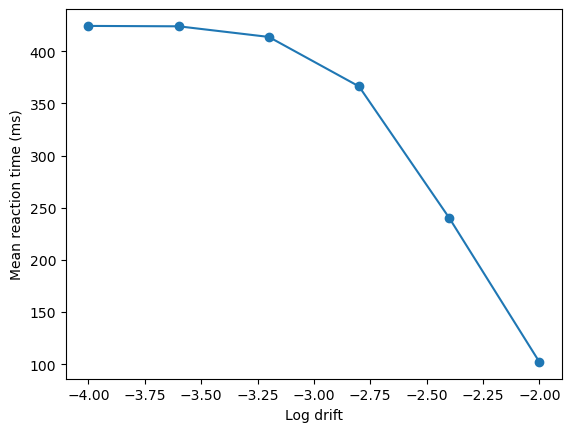

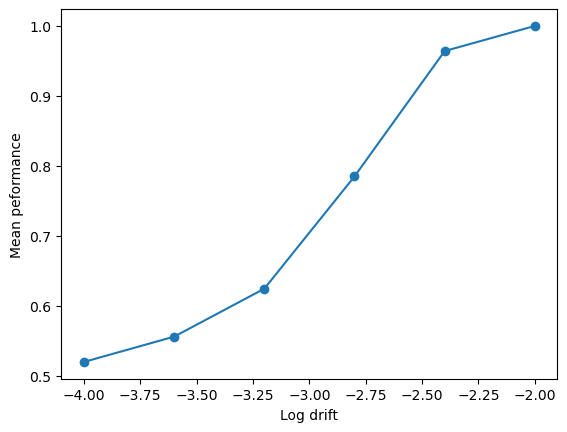

In [1]:
# -*- coding: utf-8 -*-
"""
Example code for a drift diffusion model

@author: Guangyu Robert Yang, 2017/04
"""
from __future__ import division

import warnings
import numpy as np
import matplotlib.pyplot as plt

def run_ddm(boundary, drift, noise, n_trial=1, starting_point=0.,
            dt=1., max_t=5000, rng=None):
    '''
    Running the drift diffusion model for n trials
    Evaluating all trials at once. This method is faster than evaluating trials individualy
    :param n_trial: number of trials
    :param starting_point: starting point for integration
    :param dt: unit ms
    :param max_t: unit ms
    :return:
    '''

    assert drift >= 0
    assert boundary > 0
    assert noise >= 0

    noise_ = noise * np.sqrt(dt) # change of variable
    n_t = int(max_t/dt)
    
    # Random number generator
    if rng is None:
        rng = np.random.RandomState()

    # Initialization    
    x = starting_point * np.ones(n_trial)
    notcross = np.ones(n_trial, dtype=bool)

    # Storage
    rts  = np.ones(n_trial) * max_t
    decs = np.zeros(n_trial)

    for i_t in range(n_t):
        # Update decision variable
        x += drift*dt + noise_ * rng.randn(n_trial)

        # Crossing upper boundary
        cross1 = np.logical_and(x>boundary, notcross)
        decs[cross1] = +1.
        rts[cross1] = i_t*dt

        # Crossing lower boundary
        cross2 = np.logical_and(x<-boundary, notcross)
        decs[cross2] = -1.
        rts[cross2] = i_t*dt

        # Update crossing status
        notcross[cross1] = False
        notcross[cross2] = False

    # If at the end, there are still decision variables not crossed
    if np.any(notcross):
        warnings.warn('Maximum time {:0.2f}s is likely too short'.format(max_t))

        cross1 = np.logical_and(x>0, notcross)
        decs[cross1] = +1.

        cross2 = np.logical_and(x<0, notcross)
        decs[cross2] = -1.

    # Store results and run simple analysis
    result = {'decs'        : decs,
              'rts'         : rts,
              'rt_mean'     : np.mean(rts),
              'performance' : np.sum(decs==1)/n_trial}

    return result


# Setting parameters
n_trial  = 10000

boundary = 1
drifts   = np.logspace(-4, -2, 6)
noise    = 0.05

# Storage
rt_means = list()
ps       = list()

for drift in drifts:
    result = run_ddm(boundary, drift, noise, n_trial=n_trial)
    rt_means.append(result['rt_mean'])
    ps.append(result['performance'])

# Plotting results
plt.figure()
plt.plot(np.log10(drifts), rt_means, 'o-')
plt.xlabel('Log drift')
plt.ylabel('Mean reaction time (ms)')
plt.savefig('driftdiffusionmodel_figure1.pdf')
plt.show()

plt.figure()
plt.plot(np.log10(drifts), ps, 'o-')
plt.xlabel('Log drift')
plt.ylabel('Mean peformance')
plt.savefig('driftdiffusionmodel_figure2.pdf')
plt.show()